In [1]:
# import dependencies 
# ultralytics --> model training
# supervision --> annotation
# roboflow --> importing dataset using roboflow api

!pip install ultralytics supervision roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.2/207.2 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 37.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 35.6 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 95.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s et

In [2]:
# define dir where command will running
import os 
Home = os.getcwd()
print(Home)

/kaggle/working


In [3]:
# import ultralytics and check compatibilties
import ultralytics
ultralytics.checks()

Ultralytics 8.3.189 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6411.6/8062.4 GB disk)


In [4]:
!mkdir {Home}/datasets
%cd {Home}/datasets

/kaggle/working/datasets


In [5]:
# get roboflow api key from kaggle secrets

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
ROBOFLOW_API_KEY = user_secrets.get_secret("ROBOFLOW_API_KEY")

In [6]:
# define and download the dataset from roboflow

from roboflow import Roboflow

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("visionary-lab").project("maskdetection-nj5mc-zusfv")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to MaskDetection-1 in yolov11:: 100%|██████████| 2972/2972 [00:00<00:00, 7319.82it/s]


In [7]:
# downlodaed dataset dir location
dataset.location

'/kaggle/working/datasets/MaskDetection-1'

In [9]:
# import pretrained yolov11 model

from ultralytics import YOLO
from PIL import Image
import requests

model = YOLO("yolo11n.pt")

In [11]:
# define parameters for training for model
model.train(
    mode="train",
    data=f"{dataset.location}/data.yaml",
    epochs=60,          
    imgsz=640,
    batch=16
)

Ultralytics 8.3.189 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/datasets/MaskDetection-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True

invalid value encountered in less
invalid value encountered in less


                   all        294        537      0.946      0.821       0.92      0.624
             with_mask        210        416      0.941      0.806      0.922      0.575
          without_mask         96        121      0.952      0.835      0.919      0.674
Speed: 0.2ms preprocess, 2.3ms inference, 0.0ms loss, 4.8ms postprocess per image
Results saved to runs/detect/train2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d4c2977cd10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [20]:
# load trained model and make prediction for sample image

tuned_model = YOLO("runs/detect/train2/weights/best.pt")
image = Image.open("/kaggle/working/datasets/MaskDetection-1/valid/images/10-with-mask_jpg.rf.6ba7aafb181e4c3a054f1fd5d7969a3d.jpg")
result = tuned_model.predict(image, conf=0.25)[0]


0: 640x448 1 with_mask, 9.8ms
Speed: 1.9ms preprocess, 9.8ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 448)


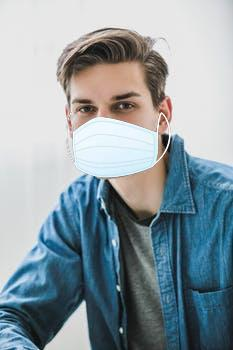

In [44]:
from IPython.display import Image as IPyImage

# show image before prediction
IPyImage(filename="/kaggle/working/datasets/MaskDetection-1/valid/images/10-with-mask_jpg.rf.6ba7aafb181e4c3a054f1fd5d7969a3d.jpg", width=300)

In [21]:
# bounding boxes of image predictions
result.boxes.xyxy

tensor([[ 63.7047,  76.7429, 164.3037, 184.6907]], device='cuda:0')

In [22]:
# confidence score of bounding boxes
result.boxes.conf

tensor([0.8617], device='cuda:0')

In [23]:
# class of bounding boxes
result.boxes.cls

tensor([0.], device='cuda:0')

In [28]:
import supervision as sv

# define detections in supervision to annotate image
detections = sv.Detections.from_ultralytics(result)

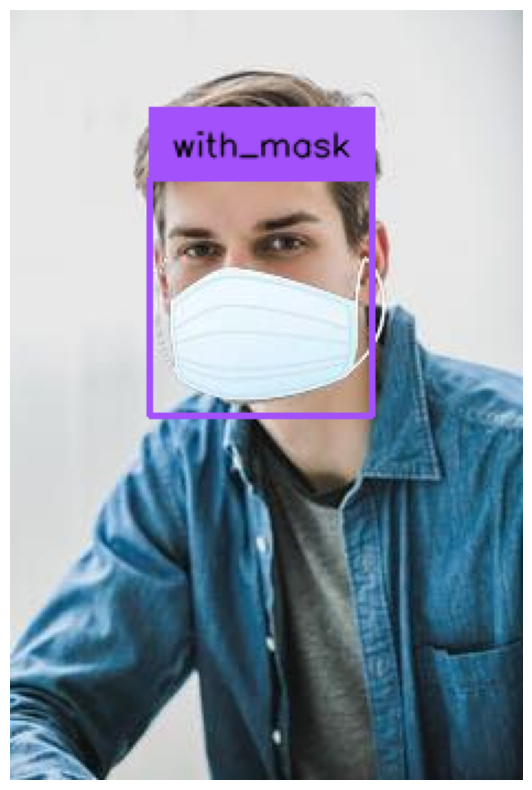

In [42]:
box_annotator = sv.BoxAnnotator() # initialize box annotator
label_annotator = sv.LabelAnnotator(text_color=sv.Color.BLACK) # initialize label annotator

annotated_image = image.copy() # make a copy of real image
annotated_image = box_annotator.annotate(annotated_image, detections=detections) # annotate box on image
annotated_image = label_annotator.annotate(annotated_image, detections=detections) # annotate labed on image
sv.plot_image(annotated_image, size=(10, 10)) # plot image

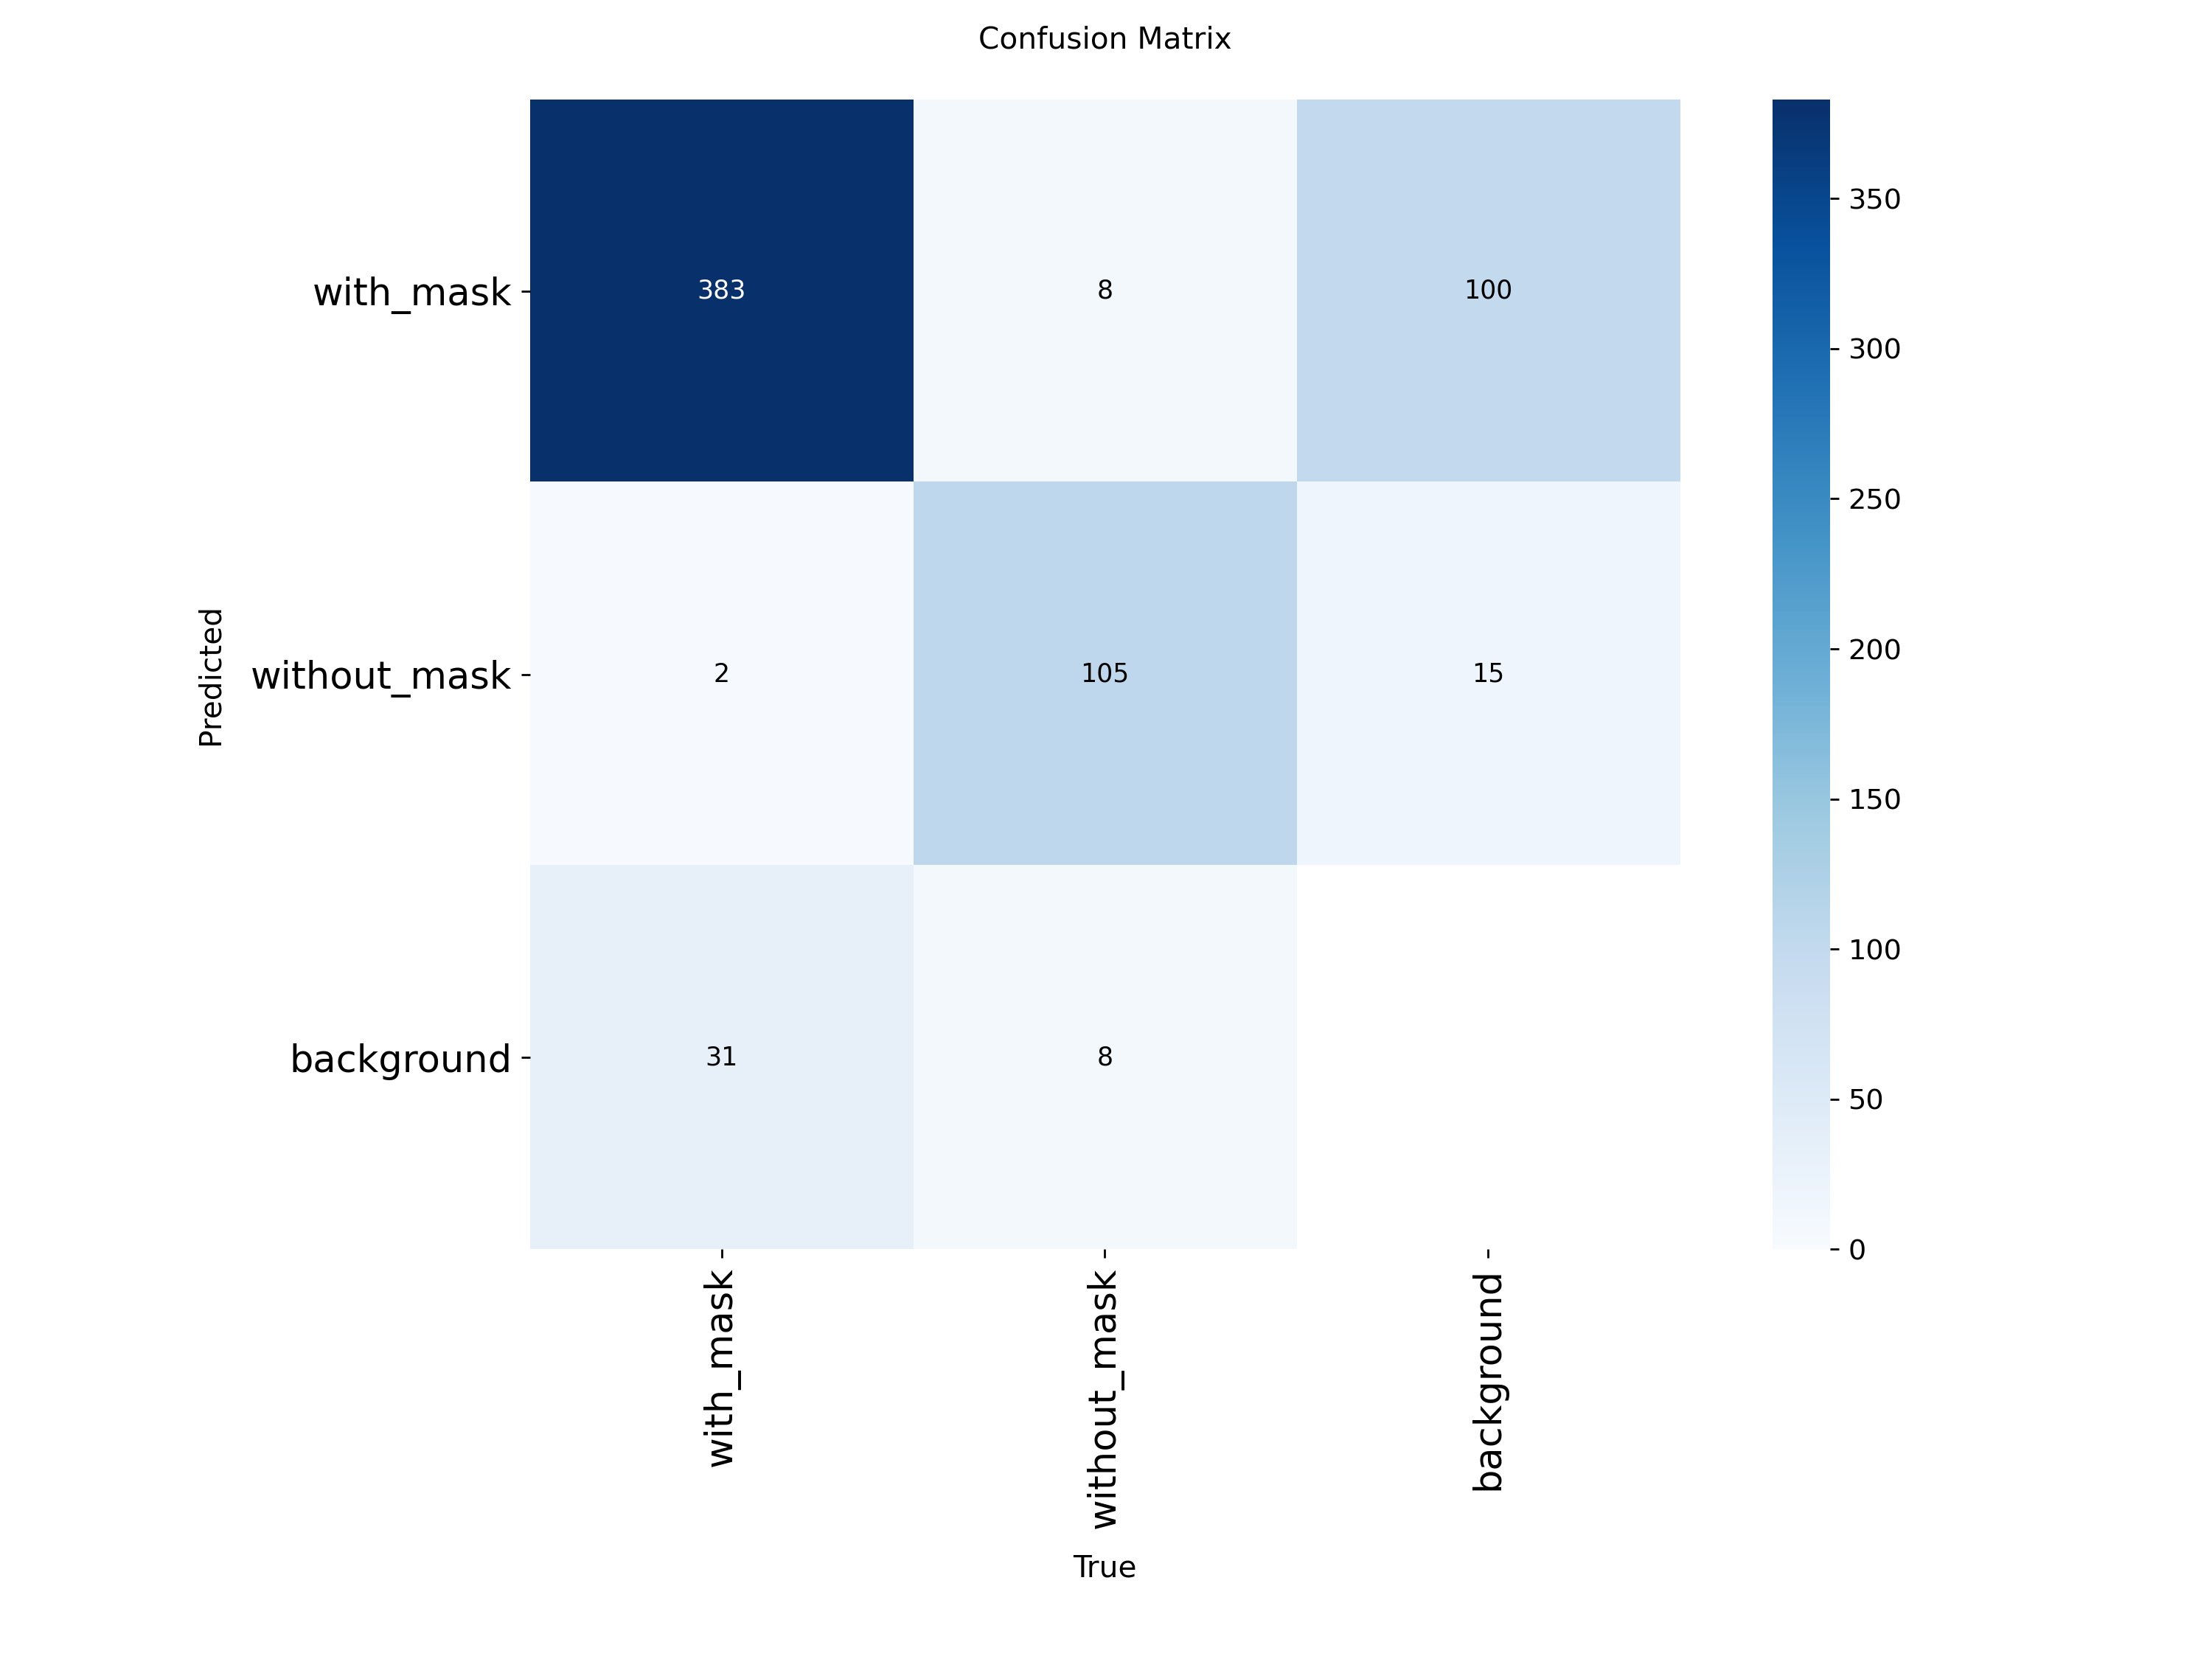

In [34]:
from IPython.display import Image as IPyImage

# display confusion metrix of trained model
IPyImage(filename="/kaggle/working/datasets/runs/detect/train2/confusion_matrix.png", width=700)

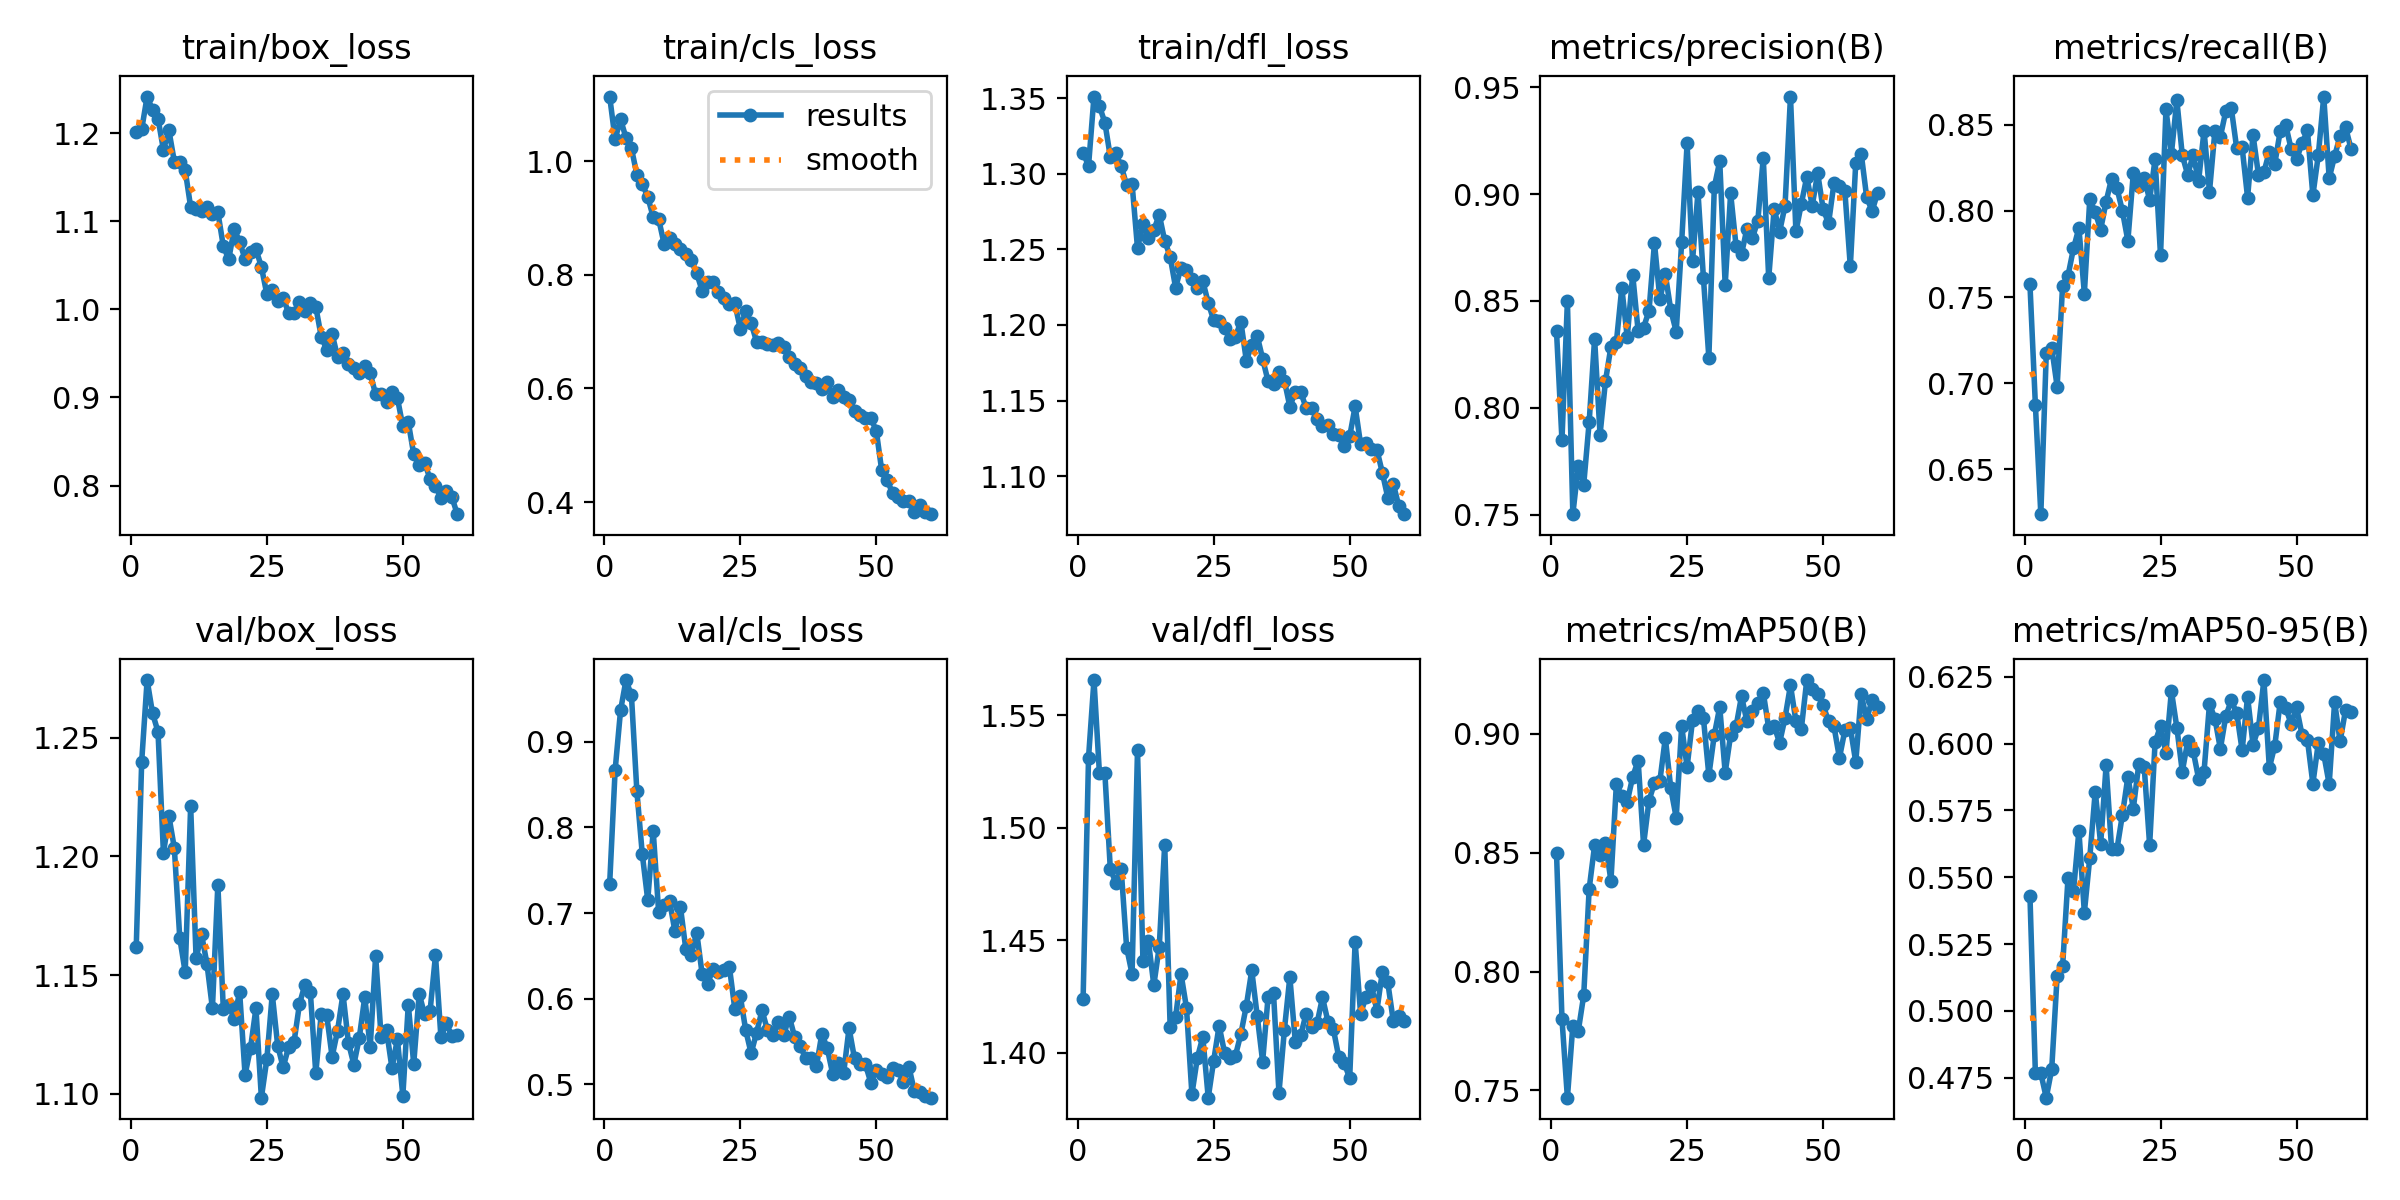

In [36]:
from IPython.display import Image as IPyImage

# train and test losses, precision, recalls
IPyImage(filename="/kaggle/working/datasets/runs/detect/train2/results.png", width=1500)

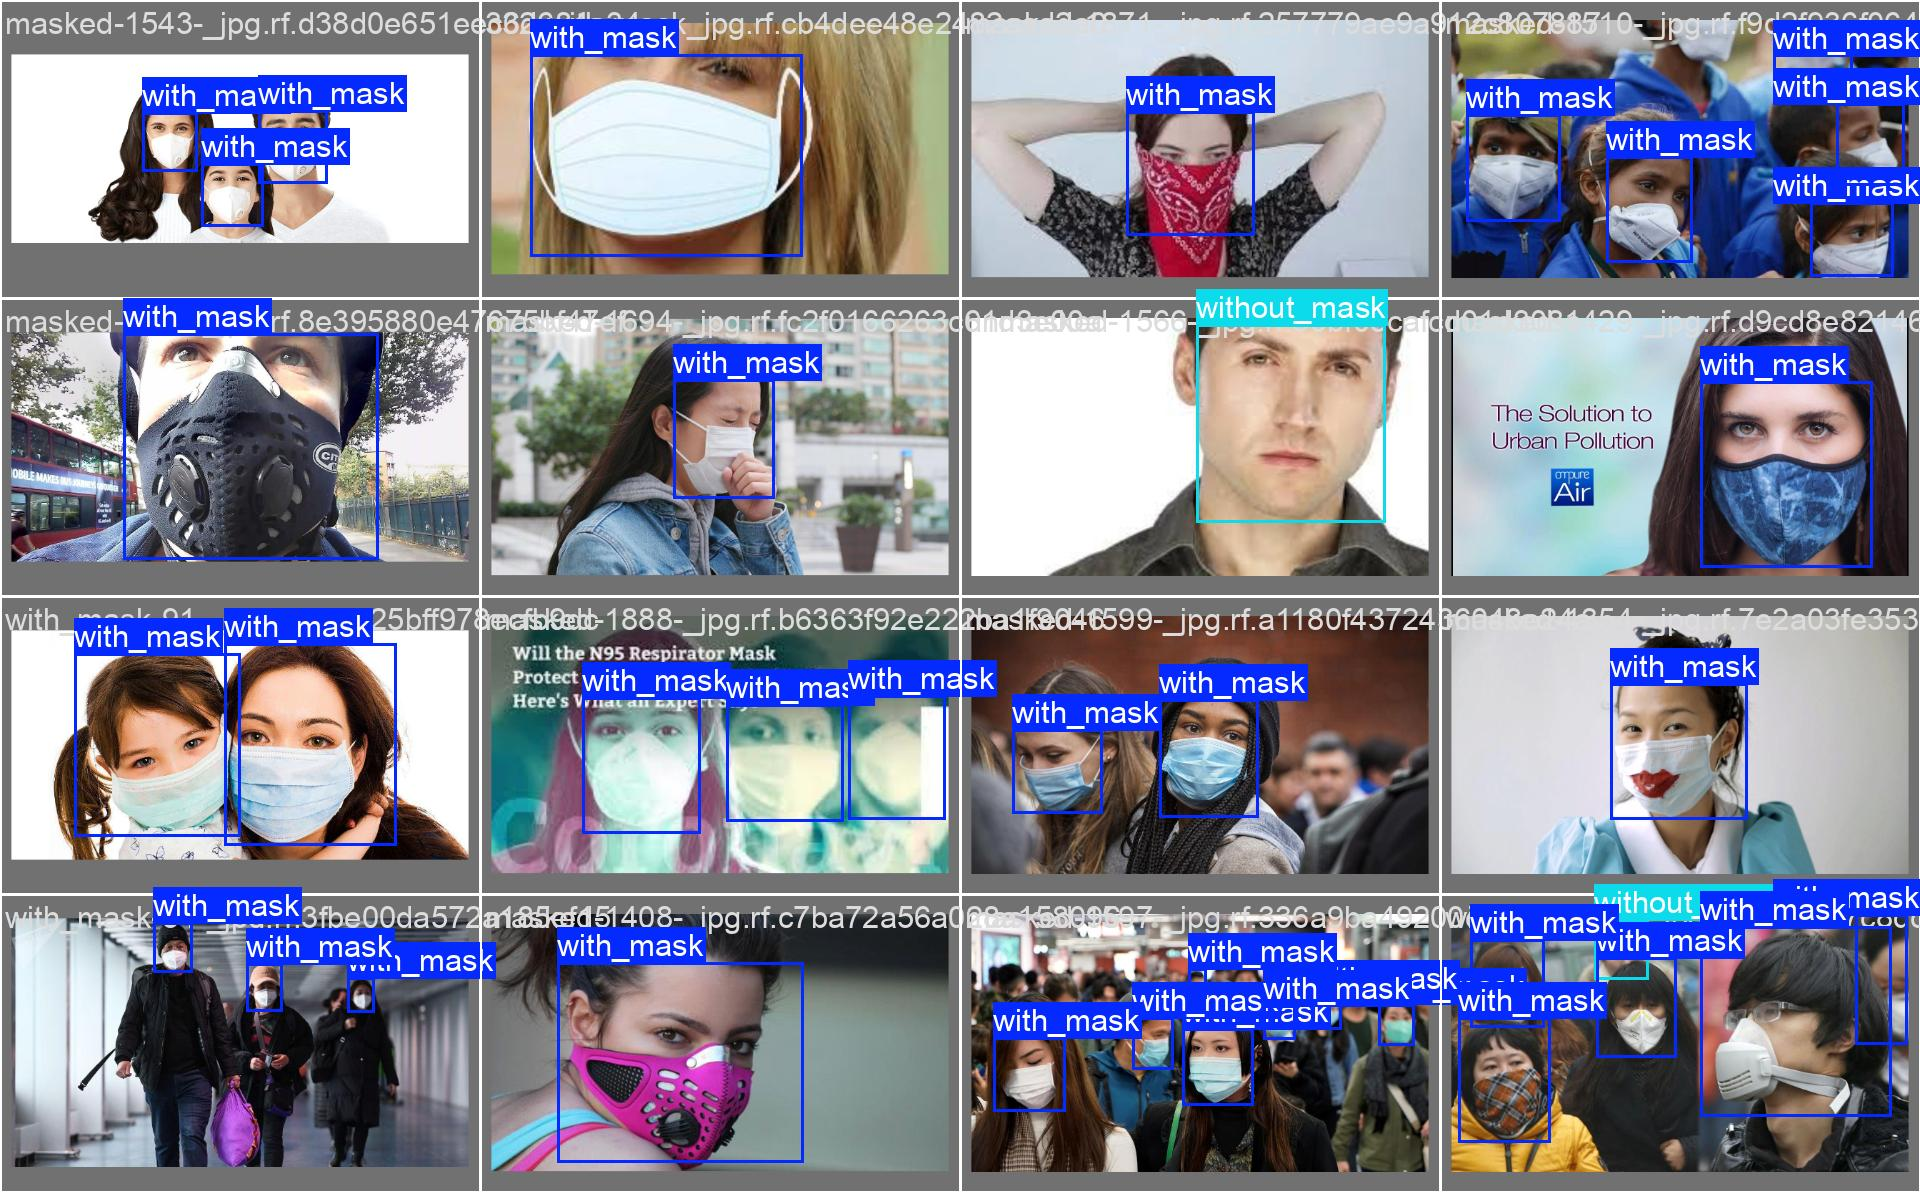

In [40]:
from IPython.display import Image as IPyImage

# labeled images of batch 0 validation data
IPyImage(filename="/kaggle/working/datasets/runs/detect/train2/val_batch0_labels.jpg", width=1500)

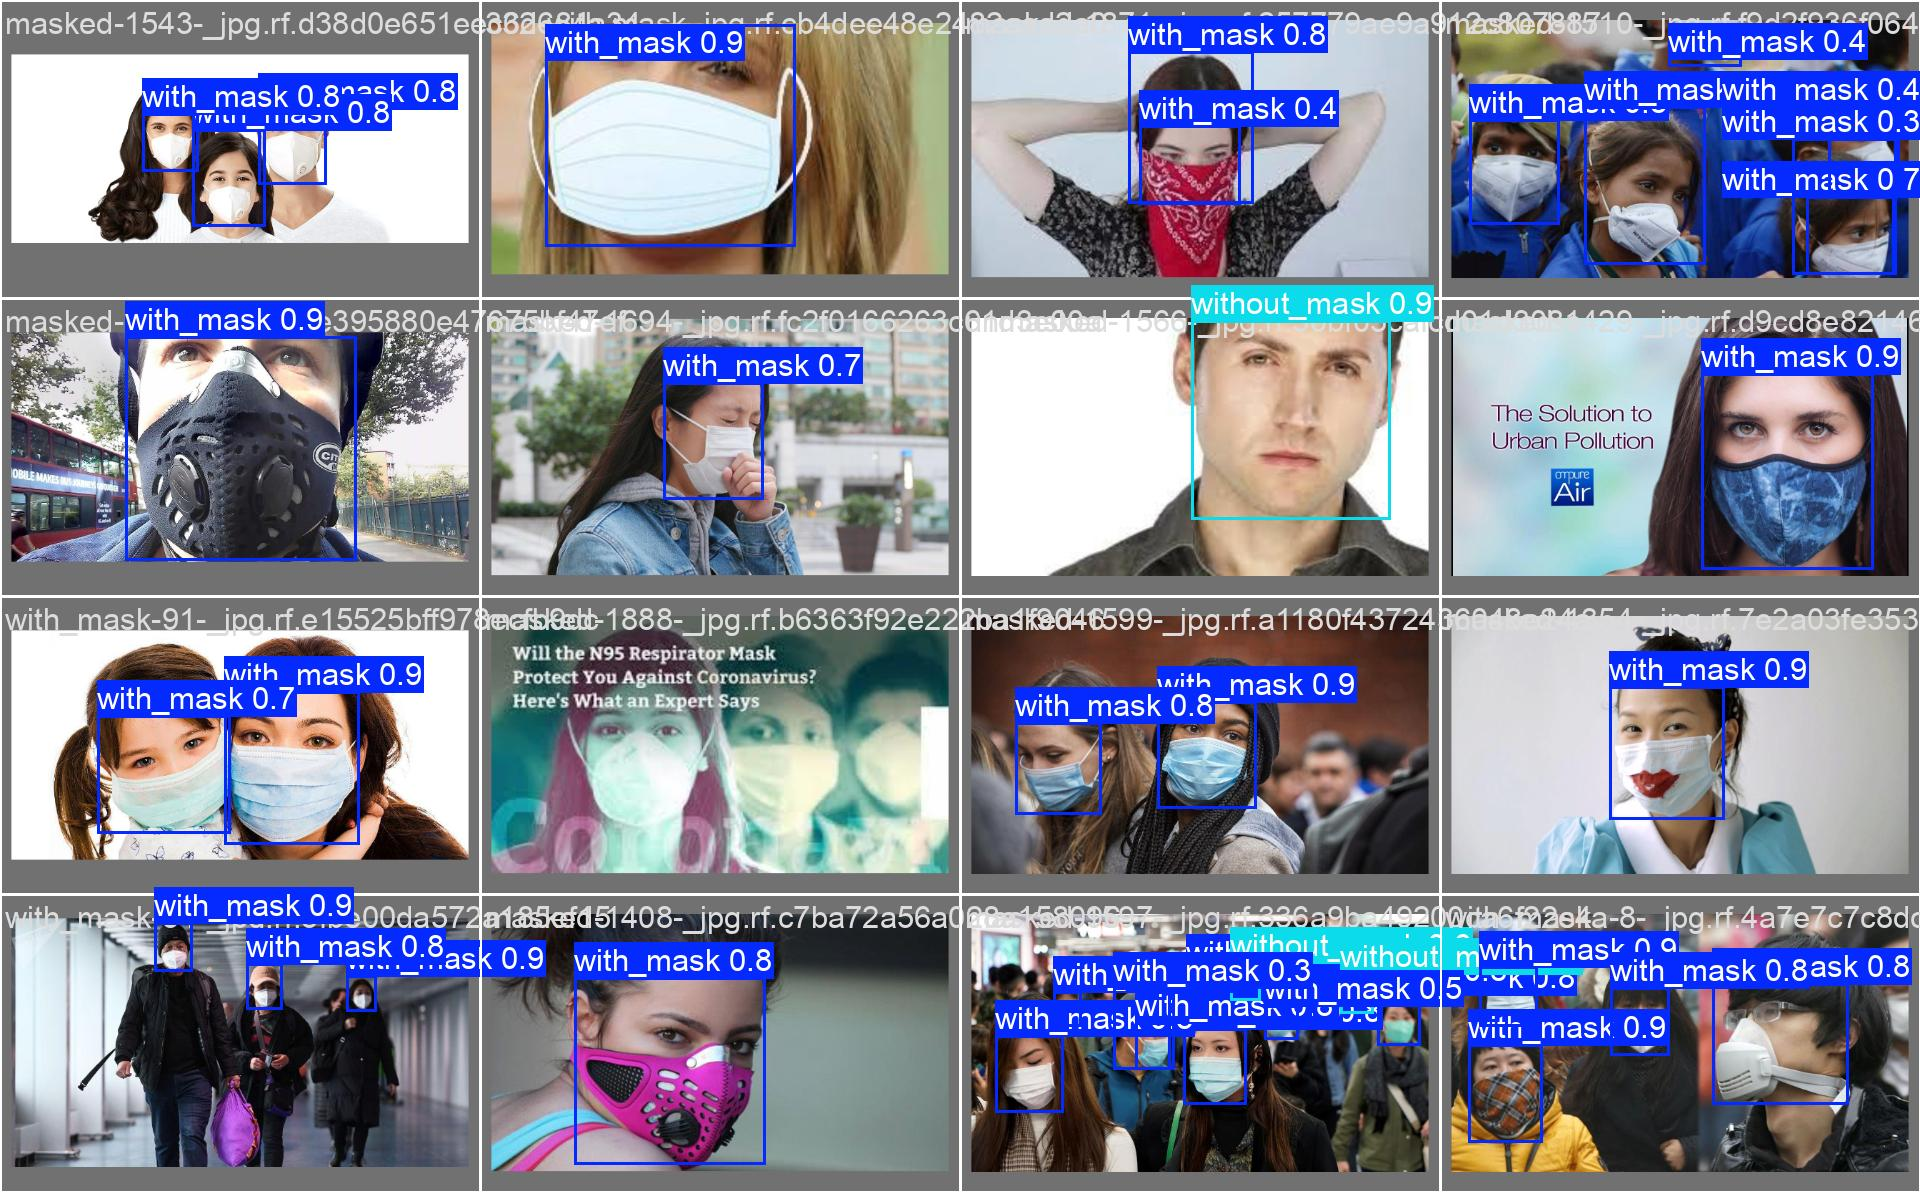

In [39]:
# predicted images of batch 0 validation data
IPyImage(filename="/kaggle/working/datasets/runs/detect/train2/val_batch0_pred.jpg", width=1500)